In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [49]:
train_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\train.csv")
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
test_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [51]:
surviving_women = train_data.loc[train_data.Sex == "female"]["Survived"]
percent_of_women_alive = sum(surviving_women)/len(surviving_women) * 100

print("% of women alive: ", percent_of_women_alive)

% of women alive:  74.20382165605095


In [52]:
surviving_men = train_data.loc[train_data.Sex == "male"]["Survived"]
percent_of_men_alive = sum(surviving_men)/len(surviving_men) * 100

print("% of men alive: ", percent_of_men_alive)

% of men alive:  18.890814558058924


In [53]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [54]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [55]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [56]:
sex_survival = pd.crosstab(train_data["Sex"], train_data["Survived"].map({ 0 : "Deceased", 1 : "Survived"}))

sex_survival.columns.name = "Survival Status"

sex_survival

Survival Status,Deceased,Survived
Sex,,
female,81,233
male,468,109


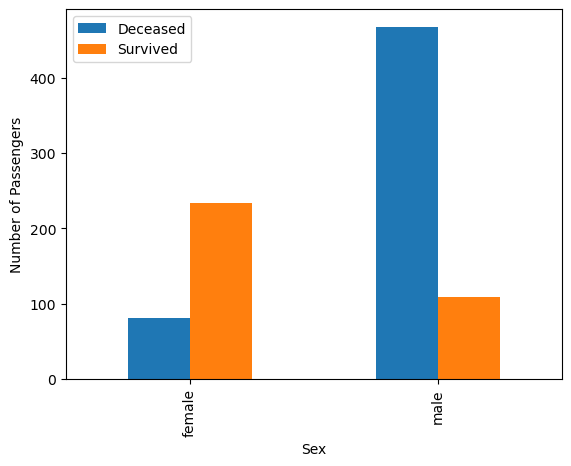

In [57]:
sex_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()

In [58]:
train_data.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [59]:
train_data["age_groups"] = pd.cut(train_data["Age"], 
                    bins = [0,10,20,30,40,50,60,70,80], 
                    labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"])

age_survival = pd.crosstab(train_data["age_groups"], train_data["Survived"].map({ 0 : "Deceased", 1 : "Survived"}))

age_survival.columns.name = "Survival Status"

age_survival

Survival Status,Deceased,Survived
age_groups,,
0-10,26,38
10-20,71,44
20-30,146,84
30-40,86,69
40-50,53,33
50-60,25,17
60-70,13,4
70-80,4,1


##### Congrats! You've now engineered your first feature - age_groups

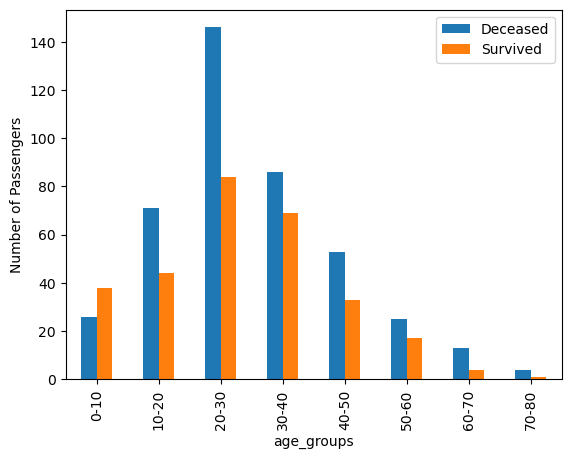

In [60]:
age_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()

In [61]:
pclass_survival = pd.crosstab(train_data["Pclass"], train_data["Survived"].map({0: "Deceased", 1: "Survived"}))

pclass_survival.columns.name = "Survival Status"

pclass_survival

Survival Status,Deceased,Survived
Pclass,,
1,80,136
2,97,87
3,372,119


In [62]:
train_data.groupby(train_data["age_groups"])["Survived"].mean()

# Note that in similar groupby operations, we put the column name
# in quotes. Here we don't use quotes because age_groups is a separate
# Pandas Series created from the Age column, rather than a column
# inside train_data.

C:\Users\sidhu\AppData\Local\Temp\ipykernel_22264\1502092888.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.groupby(train_data["age_groups"])["Survived"].mean()


age_groups
0-10     0.593750
10-20    0.382609
20-30    0.365217
30-40    0.445161
40-50    0.383721
50-60    0.404762
60-70    0.235294
70-80    0.200000
Name: Survived, dtype: float64

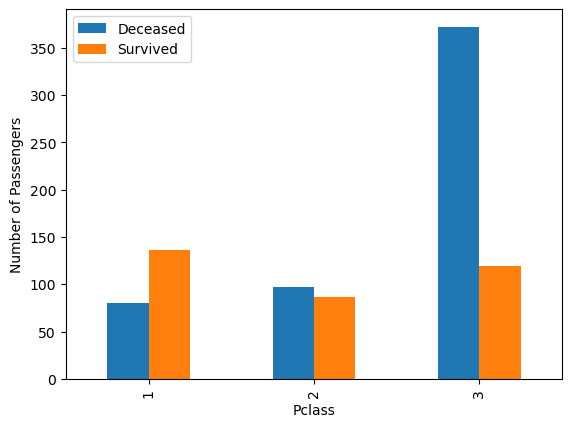

In [63]:
pclass_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()

In [64]:
train_data.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [65]:
# train_data["Embarked"] = train_data["Embarked"].map({"C": "Cherbourg",
#                            "Q": "Queenstown",
#                            "S": "Southampton"})

# train_data["Survived"] = train_data["Survived"].map({0 : "Deceased", 1 : "Survived"})


# pd.crosstab(train_data["Embarked"], train_data["Survived"])

# Avoid writing the above during EDA if we only want to temporarily rename
# values for visualization or analysis. The assignment modifies the DataFrame
# in memory (not the original CSV file), which can cause problems if the
# operation is accidentally repeated.
# The assignment is perfectly valid when you intentionally want to modify the DataFrame.
# For all EDA purposes, write as below:

embarked_survival = pd.crosstab(
    train_data["Embarked"].map({"C": "Cherbourg",
                            "Q": "Queenstown",
                            "S": "Southampton"}) ,
train_data["Survived"].map({0 : "Deceased", 
                            1 : "Survived"}
            ))

embarked_survival.columns.name = "Survival Status"

embarked_survival

Survival Status,Deceased,Survived
Embarked,,
Cherbourg,75,93
Queenstown,47,30
Southampton,427,217


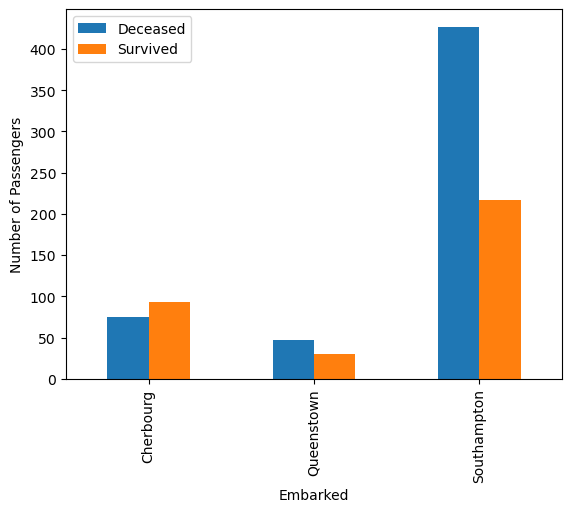

In [66]:
embarked_survival.plot(kind = "bar")

plt.ylabel("Number of Passengers")
plt.legend(title = None)
plt.show()

In [67]:
train_data.groupby("Embarked")["Survived"].mean()      

# Spose you want the full names mentioned for C, S, Q ... use this :

# train_data.assign(Embarked = train_data["Embarked"].map({ "C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})).groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [68]:
survival_by_class_sex = pd.crosstab([train_data["Pclass"], train_data["Sex"]], train_data["Survived"].map({0 : "Deceased %", 1 : "Survived %"}), normalize = "index") * 100 # normalize gives mean values
                                                                                                          # multiplying with 100 to get %
survival_by_class_sex.columns.name = "Survival Status"

survival_by_class_sex

Survival Status  Deceased %  Survived %
Pclass Sex                             
1      female      3.191489   96.808511
       male       63.114754   36.885246
2      female      7.894737   92.105263
       male       84.259259   15.740741
3      female     50.000000   50.000000
       male       86.455331   13.544669

In [69]:
train_data[["Age", "Survived"]].corr()

,Age,Survived
Age,1.000000,-0.077221
Survived,-0.077221,1.000000


##### Let us now, engineer another feature - Family Size

In [70]:
train_data["family_size"] = train_data["Parch"] + train_data["SibSp"] + 1 

# +1 because other features count parent(s), child(ren), spouse, sibling(s), 
# but there is nothing counting the passenger themselves

In [71]:
family_survival = pd.crosstab(train_data["family_size"], train_data["Survived"].map({0 : "Deceased %", 1: "Survived %"}), normalize = "index") * 100

family_survival.index.name = "Family Size"

family_survival.columns.name = "Survival Status"

family_survival

Survival Status,Deceased %,Survived %
Family Size,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


In [72]:
train_data.groupby(train_data["family_size"])["Survived"].mean() # above data is better represented but keeping this cause groupby is handy fxn for performing 
# different calculations for groups of data

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [73]:
train_data["family_size_group"] = pd.cut(train_data["family_size"], bins = [0, 1, 4, 7, 12], labels = ["Alone", "Small", "Medium", "Large"])

family_size_group_survival = pd.crosstab(train_data["family_size_group"], train_data["Survived"].map({0: "Deceased %", 1: "Survived %"}), normalize = "index") * 100

family_size_group_survival.columns.name = "Survival Status"

family_size_group_survival


# train_data.groupby("family_size_group", observed = True)["Survived"].mean() --> similar way to do above using groupby. Only shows survived mean
# does NOT show deceased mean

Survival Status,Deceased %,Survived %
family_size_group,,
Alone,69.646182,30.353818
Small,42.123288,57.876712
Medium,79.591837,20.408163
Large,100.000000,0.000000


In [74]:
train_data["is_alone"] = (train_data["family_size"] == 1).astype(int)

In [75]:
is_alone_survival = pd.crosstab(train_data["is_alone"], train_data["Survived"].map({0: "Deceased %", 1: "Survived %"}), normalize = "index") * 100

is_alone_survival.columns.name = "Survival Status"

is_alone_survival

# train_data.groupby("is_alone")["Survived"].mean()  --> similar way to do above using groupby. Only shows survived mean, does NOT show deceased mean


Survival Status,Deceased %,Survived %
is_alone,,
0,49.435028,50.564972
1,69.646182,30.353818


In [76]:
train_data["title"] = train_data["Name"].str.extract(r",\s*([^.]*)\.")

# this is regex or regular expression. read up on it

In [77]:
title_count = train_data["title"].value_counts()

title_count

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [78]:
title_survival = pd.crosstab(train_data["title"], train_data["Survived"].map({0: "Deceased %", 1: "Survived %"}), normalize = "index")[["Survived %"]] * 100

# double square brackets are important for survived in the end of the above line. else error.

title_survival = title_survival.sort_values(by = "Survived %", ascending = False)

title_survival.columns.name = "Survival Status"

# Making use of data in above cell

title_survival["count"] = title_count

title_survival

# train_data.groupby("title")["Survived"].mean().sort_values(ascending = False)

Survival Status,Survived %,count
title,,
the Countess,100.000000,1
Mlle,100.000000,2
Sir,100.000000,1
Ms,100.000000,1
Lady,100.000000,1
Mme,100.000000,1
Mrs,79.200000,125
Miss,69.780220,182
Master,57.500000,40


In [79]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

train_data["title_group"] = train_data["title"].where(train_data["title"].isin(common_titles), "rare_titles")

train_data["title_group"].value_counts()

title_group
Mr             517
Miss           182
Mrs            125
Master          40
rare_titles     27
Name: count, dtype: int64

In [80]:
title_group_survival = pd.crosstab(
    train_data["title_group"],
    train_data["Survived"].map({
        0: "Deceased %",
        1: "Survived %"
    }),
    normalize="index"
)[["Survived %"]] * 100

title_group_survival.columns.name = "Survival Status"

title_group_survival

Survival Status,Survived %
title_group,
Master,57.500000
Miss,69.780220
Mr,15.667311
Mrs,79.200000
rare_titles,44.444444


##### Now that we're moving to the modelling stage, we create copies of our train & test data

In [81]:
train_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\train.csv")

test_data = pd.read_csv(r"C:\Users\sidhu\OneDrive\Desktop\Kaggle\Titanic - Machine Learning from Disaster\data\test.csv")

##### We read the original CSVs again because we want to restore the original train_data and test_data DataFrames. This is mainly necessary for train_data, because during EDA we added several experimental features directly to it (e.g., train_data["family_size_group"]).

##### Not all of these experimental features are useful for our final model. They were created primarily for EDA, experimentation, and understanding relationships between the features and the target.

##### Some of these experimental features were not created for test_data. Therefore, if we simply copied train_data and test_data as they currently are, train would contain extra columns that are not present in test.

##### To avoid this, we reset both DataFrames to the original CSVs and will recreate only the features that we have decided to use for model building.

In [82]:
train = train_data.copy()
test = test_data.copy()

In [83]:
train["family_size"] = train["SibSp"] + train["Parch"] + 1
test["family_size"] = test["SibSp"] + test["Parch"] + 1

In [84]:
train["is_alone"] = (train["family_size"] == 1).astype(int)
test["is_alone"] = (test["family_size"] == 1).astype(int)

In [85]:
train["title"] = train["Name"].str.extract(r",\s*([^.]*)\.")
test["title"] = test["Name"].str.extract(r",\s*([^.]*)\.")

In [86]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

train["title_group"] = train["title"].where(
    train["title"].isin(common_titles),
    "rare_titles"
)

test["title_group"] = test["title"].where(
    test["title"].isin(common_titles),
    "rare_titles"
)

##### Now verifying if the columns have been added to train and test

In [87]:
train[["family_size", "is_alone", "title", "title_group"]].head()

,family_size,is_alone,title,title_group
0,2,0,Mr,Mr
1,2,0,Mrs,Mrs
2,1,1,Miss,Miss
3,2,0,Mrs,Mrs
4,1,1,Mr,Mr


In [88]:
test[["family_size", "is_alone", "title", "title_group"]].head()

,family_size,is_alone,title,title_group
0,1,1,Mr,Mr
1,2,0,Mrs,Mrs
2,1,1,Mr,Mr
3,1,1,Mr,Mr
4,3,0,Mrs,Mrs


In [91]:
features = [
    "Parch",
    "SibSp",
    "Sex",
    "Pclass",
    "Age",
    "Fare",
    "family_size",
    "is_alone",
    "Embarked",
    "title_group"
]

In [92]:
train[features].head()

,Parch,SibSp,Sex,Pclass,Age,Fare,family_size,is_alone,Embarked,title_group
0,0,1,male,3,22.0,7.2500,2,0,S,Mr
1,0,1,female,1,38.0,71.2833,2,0,C,Mrs
2,0,0,female,3,26.0,7.9250,1,1,S,Miss
3,0,1,female,1,35.0,53.1000,2,0,S,Mrs
4,0,0,male,3,35.0,8.0500,1,1,S,Mr


In [93]:
test[features].head()

,Parch,SibSp,Sex,Pclass,Age,Fare,family_size,is_alone,Embarked,title_group
0,0,0,male,3,34.5,7.8292,1,1,Q,Mr
1,0,1,female,3,47.0,7.0000,2,0,S,Mrs
2,0,0,male,2,62.0,9.6875,1,1,Q,Mr
3,0,0,male,3,27.0,8.6625,1,1,S,Mr
4,1,1,female,3,22.0,12.2875,3,0,S,Mrs


In [94]:
X = pd.get_dummies(train[features])

X_test = pd.get_dummies(test[features])

X_test = X_test.reindex(columns = X.columns, fill_value = 0)

y = train["Survived"]

In [99]:
X.shape

(891, 17)

In [100]:
X_test.shape

(418, 17)

In [98]:
X.head()

,Parch,SibSp,Pclass,Age,Fare,family_size,is_alone,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,title_group_Master,title_group_Miss,title_group_Mr,title_group_Mrs,title_group_rare_titles
0,0,1,3,22.0,7.2500,2,0,False,True,False,False,True,False,False,True,False,False
1,0,1,1,38.0,71.2833,2,0,True,False,True,False,False,False,False,False,True,False
2,0,0,3,26.0,7.9250,1,1,True,False,False,False,True,False,True,False,False,False
3,0,1,1,35.0,53.1000,2,0,True,False,False,False,True,False,False,False,True,False
4,0,0,3,35.0,8.0500,1,1,False,True,False,False,True,False,False,True,False,False


In [105]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 1
)

In [106]:
X_train.shape

(712, 17)

In [107]:
X_val.shape

(179, 17)

In [108]:
y_train.shape

(712,)

In [109]:
y_val.shape

(179,)

In [110]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=1)

In [111]:
y_predictions = model.predict(X_val)

In [114]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_predictions)

print("Validation Accuracy Percentage:", val_accuracy*100, "%")

Validation Accuracy Percentage: 79.88826815642457 %


In [ ]:
def model_evaluation(trial):

    model = RandomForestClassifier(

        n_estimators = trial.suggest_int("n_estimators", 50, 500),
        max_depth = trial.suggest_int("max_depth", 2, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        random_state = 1
    )

    model.fit(X_train, y_train)

    val_predictions = model.predict(X_val)

    val_accuracy = accuracy_score(y_val, val_predictions)

    return val_accuracy

In [119]:
import optuna

study = optuna.create_study(direction = "maximize")

study.optimize(model_evaluation, n_trials = 100)

[I 2026-09-01 00:08:35,695] A new study created in memory with name: no-name-912ec2c4-97e4-45fb-b1a3-bd69f3ede685
[I 2026-09-01 00:08:37,089] Trial 0 finished with value: 0.8435754189944135 and parameters: {'n_estimators': 431, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8435754189944135.
[I 2026-09-01 00:08:37,426] Trial 1 finished with value: 0.8435754189944135 and parameters: {'n_estimators': 137, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.8435754189944135.
[I 2026-09-01 00:08:38,541] Trial 2 finished with value: 0.8324022346368715 and parameters: {'n_estimators': 440, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8435754189944135.
[I 2026-09-01 00:08:39,186] Trial 3 finished with value: 0.8435754189944135 and parameters: {'n_estimators': 206, 'max_depth': 12, 'mi

In [124]:
print("best paramters :\n", study.best_params, "\n")

print("best model accuracy percentage :", study.best_value*100, "%")

best paramters :
 {'n_estimators': 368, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2'} 

best model accuracy percentage : 86.03351955307262 %


In [126]:
best_model = RandomForestClassifier(
    n_estimators = study.best_params["n_estimators"],
    max_depth = study.best_params["max_depth"],
    min_samples_split = study.best_params["min_samples_split"],
    min_samples_leaf = study.best_params["min_samples_leaf"],
    max_features = study.best_params["max_features"],
    random_state = 1
)

best_model.fit(X, y)

RandomForestClassifier(max_depth=23, max_features='log2', min_samples_leaf=6,
                       min_samples_split=11, n_estimators=368, random_state=1)

##### In the first run of Optuna, after 100 trials, it has stored the best combination of values for our hyperparameters. This is why we don't give ranges for each hyperparameter within RandomForestClassifier anymore.

In [127]:
test_predictions = best_model.predict(X_test)

In [132]:
output = pd.DataFrame({
                        "PassengerId": test["PassengerId"], 
                        "Survived": test_predictions
                        })

output.to_csv("../output/Submissions_v4.csv", index=False)

In [89]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
family_size      0
is_alone         0
title            0
title_group      0
dtype: int64

In [90]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
family_size      0
is_alone         0
title            0
title_group      0
dtype: int64

Missing-value handling identified but not implemented in V4. This will be incorporated and evaluated as part of V5. Here's how:

**Age** --> Fill with median

**Embarked** --> Fill with mode

**Fare** --> Fill with median

**Cabin** -->  Don't use for the time being 

As a general rule of thumb, always use :

**Mean** --> When you are handling missing values of a numerical column and the distribution of data within that column is roughly symmetric.

**Median** --> When you are handling missing values of a numerial column and the distribution of data within that column is skewed or has significant outliers.

**Mode** --> When you are handling missing values of a categorical column.

##### ---------x----------x-----------x-----------x-----------x-----------x------------x----------x-----------x-----------x-----------x-----------

##### **Major Finding: Validation Accuracy vs. Kaggle Test Accuracy**

A major finding after completing Version 4 is that my approach of repeatedly improving the model locally and trying to get very high validation accuracy before submitting to Kaggle was flawed.

In Versions 2, 3 and 4, I used the same validation set for many Optuna trials. By repeatedly testing against the same validation data, I risked overfitting to that validation set. This made the validation accuracy look better than the model actually was on completely unseen data.

The Kaggle results showed this clearly. Even though my validation accuracy kept improving from V2 to V4, V2 and V4 actually performed worse on Kaggle than V1 and V3.

| Version | Validation Accuracy | Kaggle Test Accuracy |
|:-------:|--------------------:|---------------------:|
| **V1**  | N/A — no validation set | **77.511%** |
| **V2**  | 80.447% | 76.555% |
| **V3**  | 83.240% | **77.511%** |
| **V4**  | **86.034%** | 76.555% |

This demonstrates an important machine learning principle:

**A higher validation accuracy does not necessarily mean better generalization to unseen data.**

Therefore, from Version 5 onwards, I'll focus not only on improving validation accuracy, but also on developing a more reliable validation methodology that reduces the risk of overfitting during model selection.